# 🚀 Stochastic Gradient Descent (SGD) — The Complete Guide
### From Batch GD Problems to SGD Intuition, Math, and Implementation From Scratch

> **Goal of this notebook:** Following our complete guide on Batch Gradient Descent, this notebook will teach you everything about Stochastic Gradient Descent. You'll learn why we need it, how it solves the computational and memory issues of Batch GD, how to implement it from scratch, and how it navigates non-convex loss landscapes. We will compare Batch GD and SGD extensively through visualizations.

---

## 📑 Table of Contents

1. [The Problem with Batch Gradient Descent](#part1)
2. [Introduction to Stochastic Gradient Descent (SGD)](#part2)
3. [Batch GD vs SGD: A Detailed Comparison](#part3)
4. [Coding SGD From Scratch](#part4)
5. [Visualizing the Loss Landscape: Batch vs SGD Path](#part5)
6. [Learning Schedules: Taming the Inconsistency](#part6)
7. [When to use SGD? (Non-convex Functions & Big Data)](#part7)
8. [Using `scikit-learn`'s `SGDRegressor`](#part8)
9. [Summary: Advantages and Disadvantages](#part9)
10. [Bonus: Animating the Stochastic Gradient Descent Path](#part10)\n
11. [Practice! Real-World Datasets for SGD](#part11)\n



## ⚙️ Setup
Let's import the necessary libraries and create our dataset.



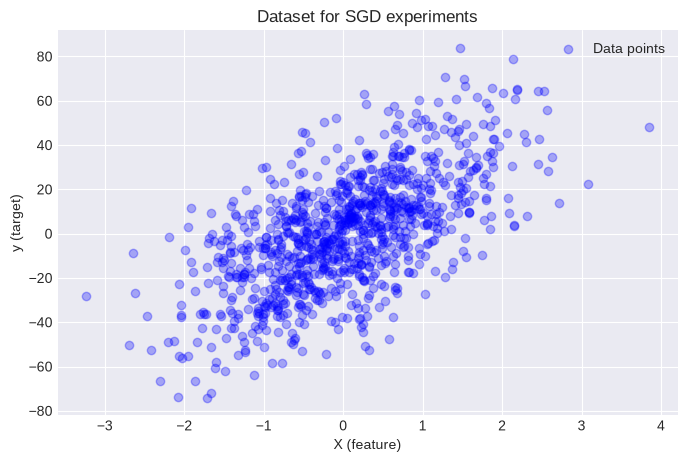

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.metrics import mean_squared_error
import time

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Generate a synthetic dataset
X, y = make_regression(n_samples=1000, n_features=1, noise=20, random_state=42)
y = y.reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.3, label='Data points')
plt.title("Dataset for SGD experiments")
plt.xlabel("X (feature)")
plt.ylabel("y (target)")
plt.legend()
plt.show()



<a id="part1"></a>
## 1. The Problem with Batch Gradient Descent

In standard **Batch Gradient Descent (BGD)**, to calculate the gradient of the cost function, we need to sum the errors over **all** training examples in the dataset.

Formula for BGD Update:
$$ \theta = \theta - \eta \cdot \frac{1}{n} \sum_{i=1}^{n} \nabla L_i(\theta) $$

### The Issues:
1. **High Computation Time:** If you have 100,000 rows (n=100,000) and you run for 1,000 epochs, you perform $100,000 \times 1,000 = 10^8$ computations. This makes it very slow on large datasets.
2. **Hardware Constraints (Memory):** BGD calculates the error on the *whole dataset* at once. This means the entire dataset must fit into the RAM. For big data, this causes out-of-memory errors.



<a id="part2"></a>
## 2. Introduction to Stochastic Gradient Descent (SGD)

To solve these problems, we introduce **Stochastic Gradient Descent**. The word *stochastic* means "random".

Instead of looking at the entire dataset to calculate the gradient, SGD picks **one random row (example)** at each step and calculates the gradient based on just that single row.

Formula for SGD Update:
$$ \theta = \theta - \eta \cdot \nabla L_i(\theta) $$
where $i$ is a random index.

### Key Characteristics:
- **Frequent Updates:** In a single epoch (one pass over the data), if there are $n$ rows, BGD makes 1 update, but SGD makes $n$ updates.
- **Low Memory:** We only need to load one row into memory at a time.
- **Randomness:** Because it only looks at one point, the path to the minimum is erratic and noisy ("inconsistent").



<a id="part3"></a>
## 3. Batch GD vs SGD: A Detailed Comparison

| Feature | Batch Gradient Descent | Stochastic Gradient Descent |
| :--- | :--- | :--- |
| **Data used per step** | Entire dataset | 1 random row |
| **Memory Requirement** | High (must load all data) | Low (loads 1 row at a time) |
| **Updates per epoch** | 1 | $n$ (number of samples) |
| **Path to minimum** | Smooth and direct | Erratic, zig-zag |
| **Convergence** | Reaches exact minimum | Reaches close to minimum, oscillates |
| **Computation speed** | Slow on large data | Fast on large data |



<a id="part4"></a>
## 4. Coding SGD From Scratch

Let's implement a simple SGD from scratch for linear regression ($y = mx + b$).



In [7]:
class SGDRegressorCustom:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self, X_train, y_train):
        # Initialize coefficients and intercept
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        
        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                # 1. Pick a random row
                idx = np.random.randint(0, X_train.shape[0])
                X_i = X_train[idx]
                y_i = y_train[idx]
                
                # 2. Predict the value for this row
                y_hat = np.dot(X_i, self.coef_) + self.intercept_
                
                # 3. Calculate gradients (derivatives) based on this SINGLE row
                intercept_der = -2 * (y_i - y_hat)
                coef_der = -2 * (y_i - y_hat) * X_i
                
                # 4. Update parameters
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)
                self.coef_ = self.coef_ - (self.lr * coef_der)
                
        return self
    
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

# Test our custom SGD
sgd_custom = SGDRegressorCustom(learning_rate=0.01, epochs=50)

start_time = time.time()
sgd_custom.fit(X, y.flatten())
sgd_time = time.time() - start_time

print(f"Custom SGD Intercept: {sgd_custom.intercept_}")
print(f"Custom SGD Coefficient: {sgd_custom.coef_}")
print(f"Time taken: {sgd_time:.4f} seconds")



Custom SGD Intercept: -2.0965196517471743
Custom SGD Coefficient: [14.87800697]
Time taken: 0.9364 seconds


<a id="part5"></a>
## 5. Visualizing the Loss Landscape: Batch vs SGD Path

Let's simulate both and plot their paths. Batch GD takes a direct route, while SGD dances around!



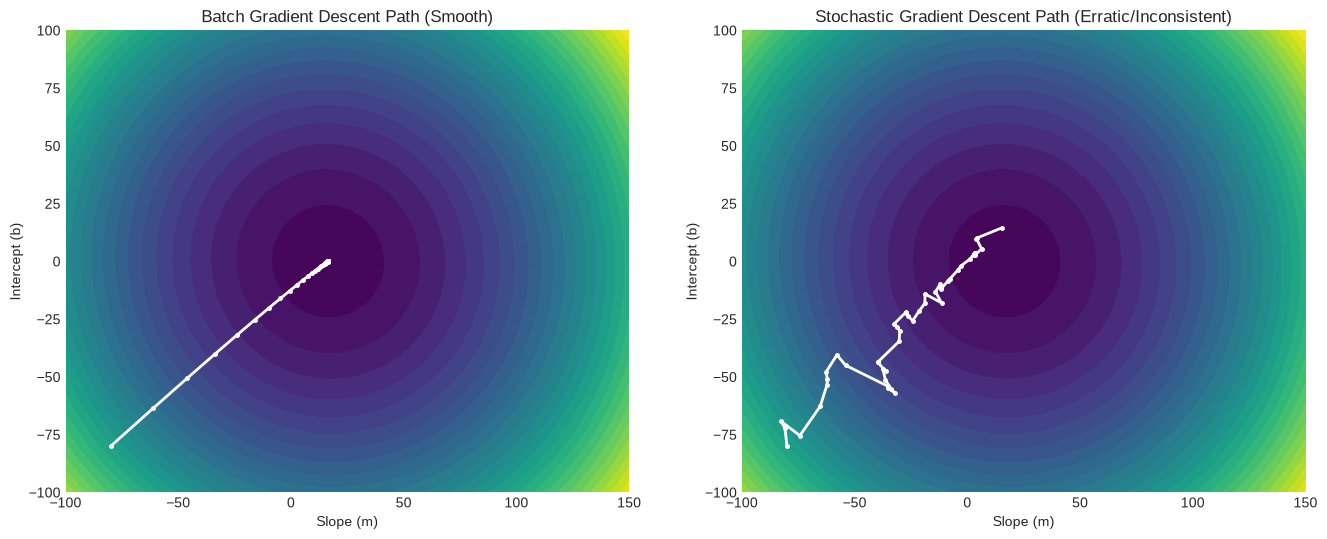

In [8]:
# Helper function to plot contour and paths
def plot_paths(X, y):
    m_vals = np.linspace(-100, 150, 50)
    b_vals = np.linspace(-100, 100, 50)
    M, B = np.meshgrid(m_vals, b_vals)
    
    Z = np.zeros_like(M)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            y_pred = M[i,j] * X.flatten() + B[i,j]
            Z[i,j] = np.mean((y.flatten() - y_pred)**2)
            
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Run Batch GD
    m_batch, b_batch = -80, -80
    lr_batch = 0.1
    m_path_b, b_path_b = [m_batch], [b_batch]
    for _ in range(50):
        y_pred = m_batch * X.flatten() + b_batch
        m_batch -= lr_batch * (-2 * np.mean((y.flatten() - y_pred) * X.flatten()))
        b_batch -= lr_batch * (-2 * np.mean(y.flatten() - y_pred))
        m_path_b.append(m_batch)
        b_path_b.append(b_batch)
        
    ax1.contourf(M, B, Z, levels=30, cmap='viridis')
    ax1.plot(m_path_b, b_path_b, color='white', marker='.', markersize=5, linewidth=2)
    ax1.set_title("Batch Gradient Descent Path (Smooth)")
    ax1.set_xlabel("Slope (m)")
    ax1.set_ylabel("Intercept (b)")
    
    # Run SGD
    m_sgd, b_sgd = -80, -80
    lr_sgd = 0.05
    m_path_s, b_path_s = [m_sgd], [b_sgd]
    for _ in range(50):
        idx = np.random.randint(0, len(X))
        x_i = X[idx][0]
        y_i = y[idx][0]
        y_pred = m_sgd * x_i + b_sgd
        m_sgd -= lr_sgd * (-2 * (y_i - y_pred) * x_i)
        b_sgd -= lr_sgd * (-2 * (y_i - y_pred))
        m_path_s.append(m_sgd)
        b_path_s.append(b_sgd)
        
    ax2.contourf(M, B, Z, levels=30, cmap='viridis')
    ax2.plot(m_path_s, b_path_s, color='white', marker='.', markersize=5, linewidth=2)
    ax2.set_title("Stochastic Gradient Descent Path (Erratic/Inconsistent)")
    ax2.set_xlabel("Slope (m)")
    ax2.set_ylabel("Intercept (b)")
    
    plt.show()

plot_paths(X, y)



<a id="part6"></a>
## 6. Learning Schedules: Taming the Inconsistency

Because SGD jumps around randomly, it never actually settles exactly at the minimum; it keeps bouncing around it. 

To fix this, we use a **Learning Schedule** (or Learning Rate Decay). 
- We start with a high learning rate so the algorithm takes big steps and learns quickly.
- As epochs increase, we gradually **decrease** the learning rate.
- This helps SGD settle down once it gets close to the global minimum.

Example of a learning schedule formula:
$$ \eta^{(t)} = \frac{t_0}{t + t_1} $$
Where $t$ is the iteration number, and $t_0, t_1$ are hyperparameters.



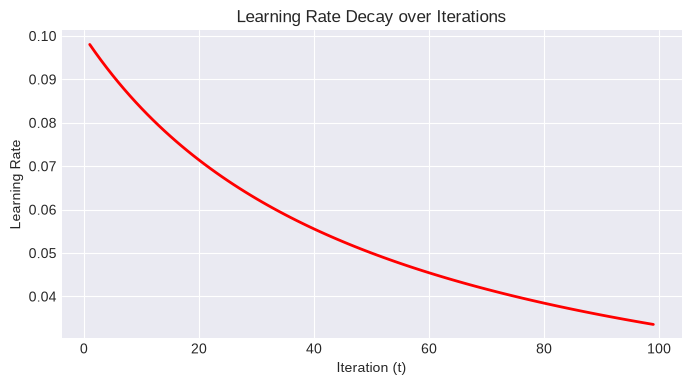

In [9]:
# Visualizing a learning schedule
epochs_list = np.arange(1, 100)
t0, t1 = 5, 50

learning_rates = [t0 / (t + t1) for t in epochs_list]

plt.figure(figsize=(8, 4))
plt.plot(epochs_list, learning_rates, color='red', linewidth=2)
plt.title("Learning Rate Decay over Iterations")
plt.xlabel("Iteration (t)")
plt.ylabel("Learning Rate")
plt.show()



<a id="part7"></a>
## 7. When to use SGD? (Non-convex Functions & Big Data)

1. **Big Data:** As discussed, BGD requires massive RAM and computation for huge datasets. SGD is the go-to algorithm for big data because it updates weights using 1 row at a time.
2. **Non-Convex Functions:** 
    - BGD has a tendency to get stuck in **Local Minima** if the loss function is non-convex (has multiple dips).
    - SGD's erratic behavior (the random bouncing) can actually act as a benefit here! The noise might help SGD **jump out** of a local minimum and find the **global minimum**.



<a id="part8"></a>
## 8. Using `scikit-learn`'s `SGDRegressor`

In practice, we don't write SGD from scratch. We use `scikit-learn`. Let's see how easy it is.



In [10]:
# Using sklearn's SGDRegressor
sgd_sk = SGDRegressor(max_iter=100, penalty=None, eta0=0.01, learning_rate='invscaling', random_state=42)

start_time = time.time()
sgd_sk.fit(X, y.flatten())
sk_time = time.time() - start_time

print(f"Sklearn SGD Intercept: {sgd_sk.intercept_[0]}")
print(f"Sklearn SGD Coefficient: {sgd_sk.coef_[0]}")
print(f"Time taken: {sk_time:.4f} seconds")



Sklearn SGD Intercept: 0.11424040814095597
Sklearn SGD Coefficient: 16.47253862762762
Time taken: 0.0045 seconds


<a id="part9"></a>
## 9. Summary: Advantages and Disadvantages

### Advantages of SGD
- **Memory Efficient:** Fits perfectly for datasets that are too large to fit in RAM.
- **Fast iterations:** Starts making progress and updating weights immediately after seeing the first example.
- **Escapes Local Minima:** The random nature helps it jump out of local optima in non-convex loss landscapes (very useful in Deep Learning).

### Disadvantages of SGD
- **Inconsistent Path:** The noisy steps mean it takes a more zig-zag path to convergence.
- **Doesn't reach exact minimum:** Without a learning schedule, it will continue to oscillate around the minimum.
- **Vectorization loss:** BGD takes full advantage of matrix-vector multiplication (vectorization) which is highly optimized on modern CPUs/GPUs. SGD processing one row at a time loses some of this benefit (which is why **Mini-batch SGD** is the ultimate compromise used in practice).



<a id="part10"></a>
## 10. Bonus: Animating the Stochastic Gradient Descent Path

Let's create an animation to clearly see how the weights update dynamically across each step. Notice how the path jumps around wildly compared to a standard Batch Gradient Descent. This behavior is precisely why it can escape local minima in complex non-convex landscapes!



In [11]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Setup figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

m_vals = np.linspace(-100, 150, 50)
b_vals = np.linspace(-100, 100, 50)
M, B = np.meshgrid(m_vals, b_vals)
Z = np.zeros_like(M)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        y_pred = M[i,j] * X.flatten() + B[i,j]
        Z[i,j] = np.mean((y.flatten() - y_pred)**2)

ax.contourf(M, B, Z, levels=30, cmap='viridis')
ax.set_title("SGD Convergence Animation")
ax.set_xlabel("Slope (m)")
ax.set_ylabel("Intercept (b)")

line, = ax.plot([], [], color='white', marker='.', markersize=5, linewidth=2)

m_sgd, b_sgd = -80, -80
lr_sgd = 0.05
m_path_s, b_path_s = [m_sgd], [b_sgd]

# Precompute 100 steps
for _ in range(100):
    idx = np.random.randint(0, len(X))
    x_i = X[idx][0]
    y_i = y[idx][0]
    y_pred = m_sgd * x_i + b_sgd
    m_sgd -= lr_sgd * (-2 * (y_i - y_pred) * x_i)
    b_sgd -= lr_sgd * (-2 * (y_i - y_pred))
    m_path_s.append(m_sgd)
    b_path_s.append(b_sgd)

def init():
    line.set_data([], [])
    return line,

def animate(i):
    line.set_data(m_path_s[:i], b_path_s[:i])
    return line,

anim = FuncAnimation(fig, animate, init_func=init, frames=len(m_path_s), interval=100, blit=True)

plt.close() # Prevent static plot from showing

# Display the animation inline
HTML(anim.to_jshtml())



<a id="part11"></a>
## 11. Practice! Real-World Datasets for SGD

Now that you've mastered SGD from scratch and visually, it's time to practice on real-world datasets. SGD is especially powerful for very large datasets where standard BGD or the Normal Equation would crash.

Here are some great datasets to practice SGD Regression on:

1. **[California Housing Prices Dataset (Kaggle)](https://www.kaggle.com/datasets/camnugent/california-housing-prices)**
   - *Goal:* Predict median house values in Californian districts.
   - *Why SGD?* It has over 20,000 rows. You can try BGD and SGD and visibly see BGD take much longer.

2. **[NYC Taxi Trip Duration (Kaggle)](https://www.kaggle.com/c/nyc-taxi-trip-duration)**
   - *Goal:* Predict the total ride duration of taxi trips in NYC.
   - *Why SGD?* This dataset contains **1.4 million rows**! Batch Gradient Descent will struggle here, making it the perfect playground for SGD or Mini-Batch SGD.

3. **[Medical Cost Personal Datasets (Kaggle)](https://www.kaggle.com/datasets/mirichoi0218/insurance)**
   - *Goal:* Predict insurance costs based on age, BMI, smoking status, etc.
   - *Why SGD?* A great smaller dataset (1.3k rows) to practice multi-variable SGD from scratch without relying on `scikit-learn`.

4. **[Superconductivity Data (UCI Machine Learning Repository)](https://archive.ics.uci.edu/ml/datasets/Superconductivty+Data)**
   - *Goal:* Predict the critical temperature of a superconductor.
   - *Why SGD?* Contains 21,000+ rows and 81 features. A solid test for high-dimensional gradient descent and feature scaling.

### 💡 Quick tip before you start:
> Always remember to **scale your features** (e.g., using `StandardScaler` from sklearn) before running Stochastic Gradient Descent! Without feature scaling, the gradients can wildly explode or take forever to converge, especially in high-dimensional datasets.

